<a href="https://colab.research.google.com/github/sushants05-ops/ECGR-4105---Intro-to-Machine-Learning/blob/main/ECGR_4105_Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (545, 13)
Training samples: 436
Validation samples: 109
Problem 1(a)
Selected learning rate: 0.08

Parameters:
theta_0 = 4706527.385321096
theta_1 (area) = 680058.4241412323
theta_2 (bedrooms) = 112973.18562908645
theta_3 (bathrooms) = 565408.6179360112
theta_4 (stories) = 424354.8117635285
theta_5 (parking) = 288348.77266769804

Training MSE: 1350008211326.58
Validation MSE: 2292721545725.367

Training RMSE: 1161898.5374491957
Validation RMSE: 1514173.552049225

Training R^2: 0.5621678833074252
Validation R^2: 0.5464062355495861


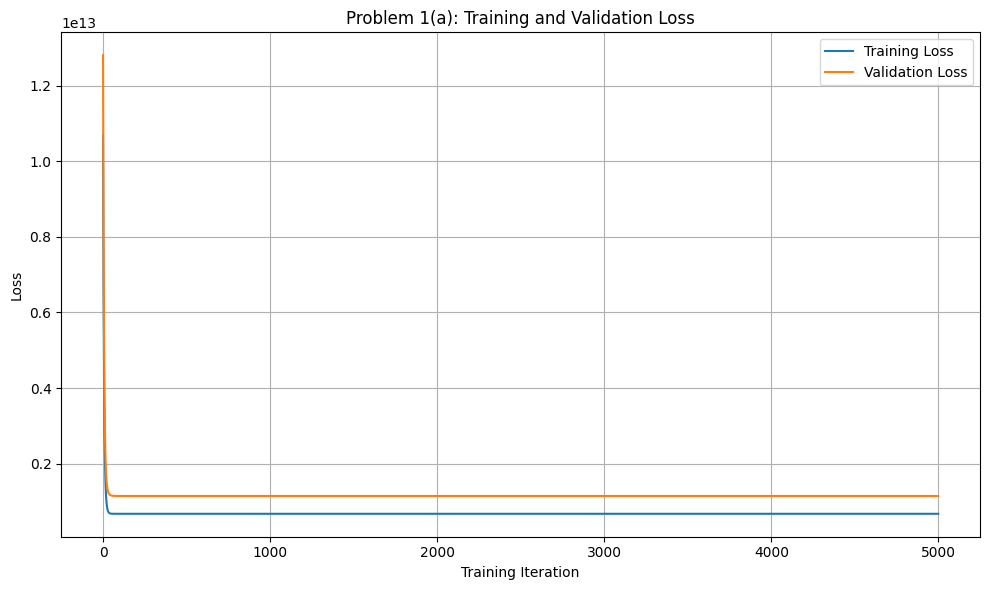

Problem 1(b)
Selected learning rate: 0.01

Parameters:
theta_0 = 4706527.385321056
theta_1 (area) = 523387.2754370558
theta_2 (bedrooms) = 58623.06251992409
theta_3 (bathrooms) = 528975.1076152895
theta_4 (stories) = 365907.5803208053
theta_5 (mainroad) = 144130.6078398208
theta_6 (guestroom) = 93366.504850681
theta_7 (basement) = 208520.890236355
theta_8 (hotwaterheating) = 155907.28692177986
theta_9 (airconditioning) = 372995.82856845256
theta_10 (parking) = 211306.4883859833
theta_11 (prefarea) = 269576.16565297265

Training MSE: 992481000009.7853
Validation MSE: 1800793719668.905

Training RMSE: 996233.4063911857
Validation RMSE: 1341936.5557539987

Training R^2: 0.6781204341087314
Validation R^2: 0.643729608671316


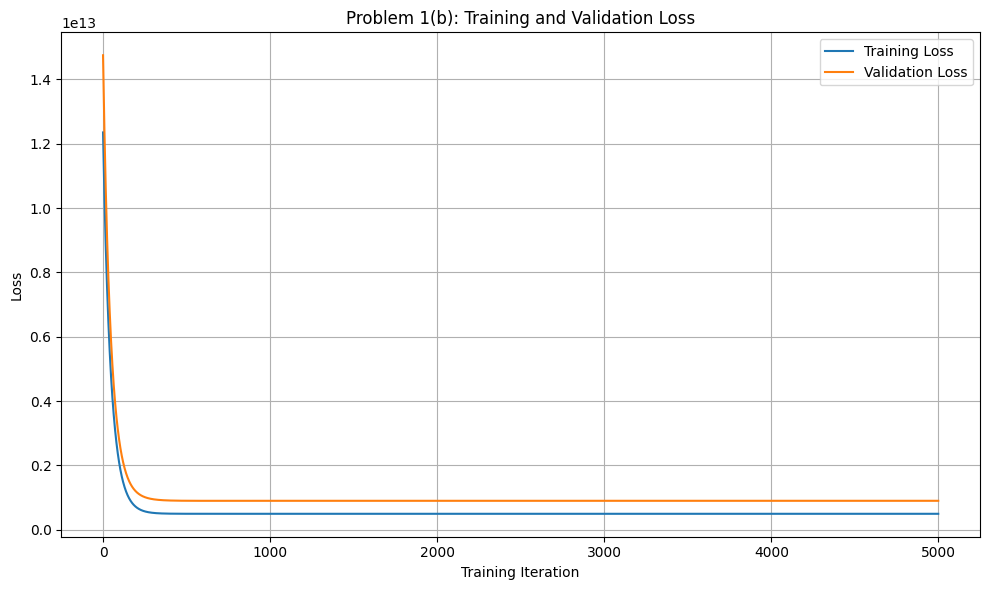

Problem 2(a)
Normalization learning rate: 0.06999999999999999
Standardization learning rate: 0.08

Normalization
Training R^2: 0.5621665923349142
Validation R^2: 0.5464349786466947
Training RMSE: 1161900.25040938
Validation RMSE: 1514125.576602527

Standardization
Training R^2: 0.5621678833074252
Validation R^2: 0.5464062355495861
Training RMSE: 1161898.5374491957
Validation RMSE: 1514173.552049225


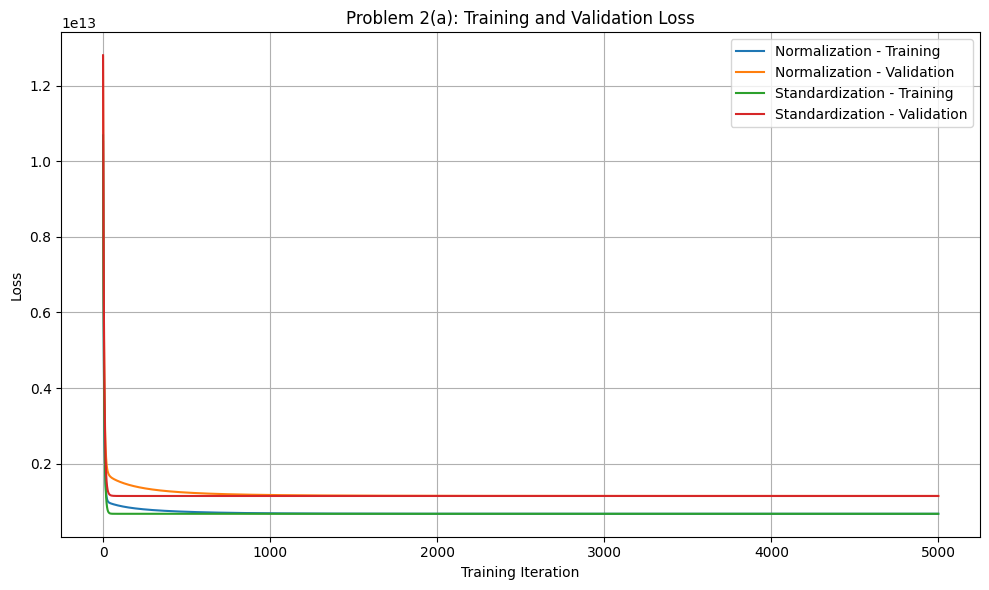


Best scaling for Problem 3(a): Normalization
Problem 2(b)
Normalization learning rate: 0.02
Standardization learning rate: 0.01

Normalization
Training R^2: 0.6754137336884787
Validation R^2: 0.6470649487568203
Training RMSE: 1000413.3243086765
Validation RMSE: 1335640.299224018

Standardization
Training R^2: 0.6781204341087314
Validation R^2: 0.643729608671316
Training RMSE: 996233.4063911857
Validation RMSE: 1341936.5557539987


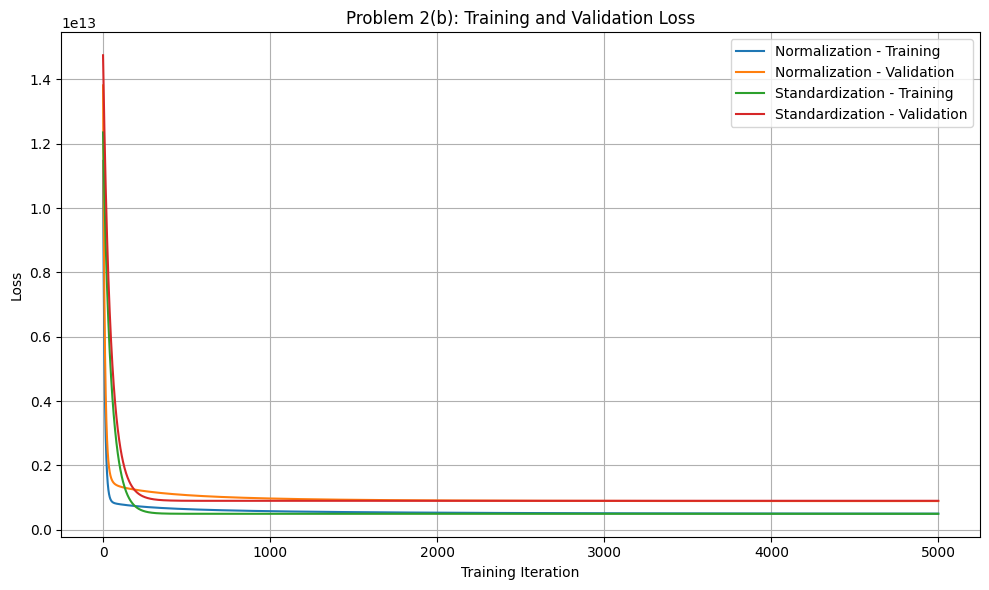


Best scaling for Problem 3(b): Normalization
Problem 3(a)
Best lambda: 0.001

Parameters:
theta_0 = 2389921.8438004386
theta_1 (area) = 4490277.340886139
theta_2 (bedrooms) = 770515.0668057252
theta_3 (bathrooms) = 3548964.0370228747
theta_4 (stories) = 1483663.4090630875
theta_5 (parking) = 1013870.6229252496

Training R^2: 0.5621665420873541
Validation R^2: 0.5464291025703761

Training RMSE: 1161900.3170816007
Validation RMSE: 1514135.384555311


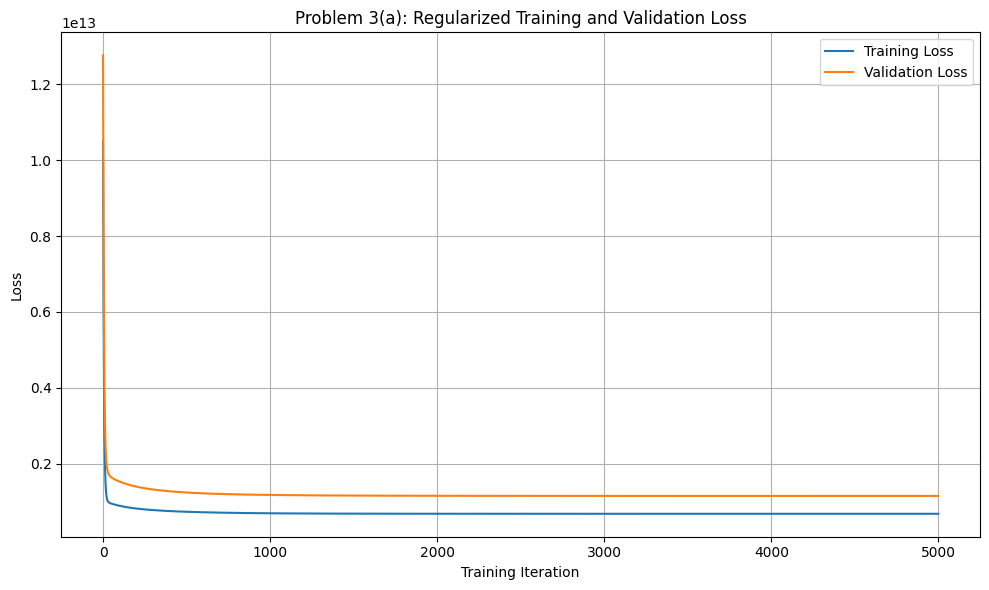

Problem 3(b)
Best lambda: 0.001

Parameters:
theta_0 = 1848562.3350330896
theta_1 (area) = 2996602.8033852093
theta_2 (bedrooms) = 802452.9884525865
theta_3 (bathrooms) = 2958890.6998081473
theta_4 (stories) = 1248946.6856157822
theta_5 (mainroad) = 466373.9311386475
theta_6 (guestroom) = 278646.24045577267
theta_7 (basement) = 416673.41367722873
theta_8 (hotwaterheating) = 721699.86616266
theta_9 (airconditioning) = 830103.4477469869
theta_10 (parking) = 841083.6855812029
theta_11 (prefarea) = 643941.0323889132

Training R^2: 0.6754118319231104
Validation R^2: 0.6470619372484487

Training RMSE: 1000416.2550374607
Validation RMSE: 1335645.9975576745


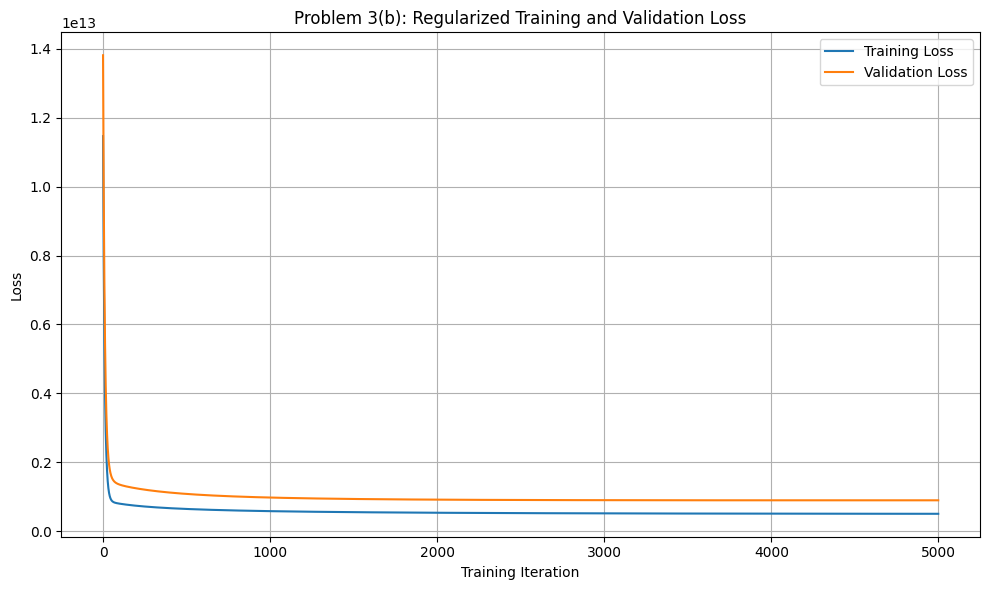

Final Comparison
             Problem  Training R2  Validation R2  Training RMSE  Validation RMSE
       1(a) Baseline     0.562168       0.546406   1.161899e+06     1.514174e+06
       1(b) Baseline     0.678120       0.643730   9.962334e+05     1.341937e+06
  2(a) Normalization     0.562167       0.546435   1.161900e+06     1.514126e+06
2(a) Standardization     0.562168       0.546406   1.161899e+06     1.514174e+06
  2(b) Normalization     0.675414       0.647065   1.000413e+06     1.335640e+06
2(b) Standardization     0.678120       0.643730   9.962334e+05     1.341937e+06
    3(a) Regularized     0.562167       0.546429   1.161900e+06     1.514135e+06
    3(b) Regularized     0.675412       0.647062   1.000416e+06     1.335646e+06
Learning Rates
Problem 1(a): 0.08
Problem 1(b): 0.01
Problem 2(a) Normalization: 0.06999999999999999
Problem 2(a) Standardization: 0.08
Problem 2(b) Normalization: 0.02
Problem 2(b) Standardization: 0.01
Regularization
Problem 3(a) lambda: 0.001
Problem 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score



# Load Dataset
data = pd.read_csv("Housing.csv")

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    data[col] = data[col].map({"yes": 1, "no": 0})


features_5 = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

features_11 = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea"
]

target = "price"



# Prepare Data
X5 = data[features_5].values.astype(float)
X11 = data[features_11].values.astype(float)
y = data[target].values.astype(float)

indices = np.arange(len(data))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42
)

X5_train = X5[train_indices]
X5_test = X5[test_indices]

X11_train = X11[train_indices]
X11_test = X11[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


print("Dataset shape:", data.shape)
print("Training samples:", len(y_train))
print("Validation samples:", len(y_test))



# Helper Functions
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]


def mse_loss(X, y, theta):
    predictions = X @ theta
    errors = predictions - y
    return np.mean(errors ** 2) / 2


def gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    iterations,
    lam=0
):

    theta = np.zeros(X_train.shape[1])

    train_losses = []
    val_losses = []

    for i in range(iterations):

        predictions = X_train @ theta
        errors = predictions - y_train

        gradient = (X_train.T @ errors) / len(y_train)

        if lam > 0:
            penalty_gradient = (lam / len(y_train)) * theta
            penalty_gradient[0] = 0
            gradient = gradient + penalty_gradient

        theta = theta - learning_rate * gradient

        train_loss = mse_loss(X_train, y_train, theta)

        if lam > 0:
            train_loss += (
                lam / (2 * len(y_train))
            ) * np.sum(theta[1:] ** 2)

        val_loss = mse_loss(X_val, y_val, theta)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses


def evaluate(X, y, theta):

    predictions = X @ theta

    mse = np.mean((predictions - y) ** 2)

    rmse = np.sqrt(mse)

    r2 = r2_score(y, predictions)

    return mse, rmse, r2


def plot_loss(train_loss, val_loss, title):

    plt.figure(figsize=(10, 6))

    plt.plot(
        train_loss,
        label="Training Loss"
    )

    plt.plot(
        val_loss,
        label="Validation Loss"
    )

    plt.xlabel("Training Iteration")
    plt.ylabel("Loss")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()


def plot_scaling(
    train_norm,
    val_norm,
    train_std,
    val_std,
    title
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        train_norm,
        label="Normalization - Training"
    )

    plt.plot(
        val_norm,
        label="Normalization - Validation"
    )

    plt.plot(
        train_std,
        label="Standardization - Training"
    )

    plt.plot(
        val_std,
        label="Standardization - Validation"
    )

    plt.xlabel("Training Iteration")
    plt.ylabel("Loss")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()


def print_theta(theta, features):

    print("\nParameters:")

    print("theta_0 =", theta[0])

    for i, feature in enumerate(features):

        print(
            "theta_" + str(i + 1),
            "(" + feature + ") =",
            theta[i + 1]
        )


# Learning Rate Search
learning_rates = np.arange(
    0.01,
    0.101,
    0.01
)


def find_stable_learning_rate(
    X_train,
    y_train,
    X_val,
    y_val,
    iterations
):

    stable_results = []

    for lr in learning_rates:

        theta, train_loss, val_loss = gradient_descent(
            X_train,
            y_train,
            X_val,
            y_val,
            lr,
            iterations
        )

        final_train = train_loss[-1]
        final_val = val_loss[-1]

        if (
            np.isfinite(final_train)
            and
            np.isfinite(final_val)
        ):

            if (
                final_train < 1e30
                and
                final_val < 1e30
            ):

                stable_results.append(
                    (lr, final_val)
                )

    if len(stable_results) == 0:

        raise ValueError(
            "No stable learning rate found between 0.01 and 0.10."
        )

    stable_results.sort(
        key=lambda x: x[1]
    )

    return stable_results[0][0]



# Problem 1(a)
print("Problem 1(a)")

# Scale X5_train and X5_test
scaler_1a = StandardScaler()
X5_train_scaled = scaler_1a.fit_transform(X5_train)
X5_test_scaled = scaler_1a.transform(X5_test)

X5_train_bias = add_bias(X5_train_scaled)
X5_test_bias = add_bias(X5_test_scaled)

iterations_1 = 5000

best_lr_1a = find_stable_learning_rate(
    X5_train_bias,
    y_train,
    X5_test_bias,
    y_test,
    iterations_1
)

print(
    "Selected learning rate:",
    best_lr_1a
)

theta_1a, train_loss_1a, val_loss_1a = gradient_descent(
    X5_train_bias,
    y_train,
    X5_test_bias,
    y_test,
    best_lr_1a,
    iterations_1
)

mse_train_1a, rmse_train_1a, r2_train_1a = evaluate(
    X5_train_bias,
    y_train,
    theta_1a
)

mse_val_1a, rmse_val_1a, r2_val_1a = evaluate(
    X5_test_bias,
    y_test,
    theta_1a
)

print_theta(theta_1a, features_5)

print("\nTraining MSE:", mse_train_1a)
print("Validation MSE:", mse_val_1a)

print("\nTraining RMSE:", rmse_train_1a)
print("Validation RMSE:", rmse_val_1a)

print("\nTraining R^2:", r2_train_1a)
print("Validation R^2:", r2_val_1a)

plot_loss(
    train_loss_1a,
    val_loss_1a,
    "Problem 1(a): Training and Validation Loss"
)



# Problem 1(b)
print("Problem 1(b)")

# Scale X11_train and X11_test
scaler_1b = StandardScaler()
X11_train_scaled = scaler_1b.fit_transform(X11_train)
X11_test_scaled = scaler_1b.transform(X11_test)

X11_train_bias = add_bias(X11_train_scaled)
X11_test_bias = add_bias(X11_test_scaled)

best_lr_1b = find_stable_learning_rate(
    X11_train_bias,
    y_train,
    X11_test_bias,
    y_test,
    iterations_1
)

print(
    "Selected learning rate:",
    best_lr_1b
)

theta_1b, train_loss_1b, val_loss_1b = gradient_descent(
    X11_train_bias,
    y_train,
    X11_test_bias,
    y_test,
    best_lr_1b,
    iterations_1
)

mse_train_1b, rmse_train_1b, r2_train_1b = evaluate(
    X11_train_bias,
    y_train,
    theta_1b
)

mse_val_1b, rmse_val_1b, r2_val_1b = evaluate(
    X11_test_bias,
    y_test,
    theta_1b
)

print_theta(theta_1b, features_11)

print("\nTraining MSE:", mse_train_1b)
print("Validation MSE:", mse_val_1b)

print("\nTraining RMSE:", rmse_train_1b)
print("Validation RMSE:", rmse_val_1b)

print("\nTraining R^2:", r2_train_1b)
print("Validation R^2:", r2_val_1b)

plot_loss(
    train_loss_1b,
    val_loss_1b,
    "Problem 1(b): Training and Validation Loss"
)


# Problem 2(a)
print("Problem 2(a)")

normalizer_5 = MinMaxScaler()

X5_train_norm = normalizer_5.fit_transform(
    X5_train
)

X5_test_norm = normalizer_5.transform(
    X5_test
)

X5_train_norm_bias = add_bias(
    X5_train_norm
)

X5_test_norm_bias = add_bias(
    X5_test_norm
)


standardizer_5 = StandardScaler()

X5_train_std = standardizer_5.fit_transform(
    X5_train
)

X5_test_std = standardizer_5.transform(
    X5_test
)

X5_train_std_bias = add_bias(
    X5_train_std
)

X5_test_std_bias = add_bias(
    X5_test_std
)


iterations_2 = 5000


best_lr_2a_norm = find_stable_learning_rate(
    X5_train_norm_bias,
    y_train,
    X5_test_norm_bias,
    y_test,
    iterations_2
)

best_lr_2a_std = find_stable_learning_rate(
    X5_train_std_bias,
    y_train,
    X5_test_std_bias,
    y_test,
    iterations_2
)


print(
    "Normalization learning rate:",
    best_lr_2a_norm
)

print(
    "Standardization learning rate:",
    best_lr_2a_std
)


theta_2a_norm, train_loss_2a_norm, val_loss_2a_norm = gradient_descent(
    X5_train_norm_bias,
    y_train,
    X5_test_norm_bias,
    y_test,
    best_lr_2a_norm,
    iterations_2
)


theta_2a_std, train_loss_2a_std, val_loss_2a_std = gradient_descent(
    X5_train_std_bias,
    y_train,
    X5_test_std_bias,
    y_test,
    best_lr_2a_std,
    iterations_2
)


mse_train_2a_norm, rmse_train_2a_norm, r2_train_2a_norm = evaluate(
    X5_train_norm_bias,
    y_train,
    theta_2a_norm
)

mse_val_2a_norm, rmse_val_2a_norm, r2_val_2a_norm = evaluate(
    X5_test_norm_bias,
    y_test,
    theta_2a_norm
)


mse_train_2a_std, rmse_train_2a_std, r2_train_2a_std = evaluate(
    X5_train_std_bias,
    y_train,
    theta_2a_std
)

mse_val_2a_std, rmse_val_2a_std, r2_val_2a_std = evaluate(
    X5_test_std_bias,
    y_test,
    theta_2a_std
)


print("\nNormalization")
print("Training R^2:", r2_train_2a_norm)
print("Validation R^2:", r2_val_2a_norm)
print("Training RMSE:", rmse_train_2a_norm)
print("Validation RMSE:", rmse_val_2a_norm)


print("\nStandardization")
print("Training R^2:", r2_train_2a_std)
print("Validation R^2:", r2_val_2a_std)
print("Training RMSE:", rmse_train_2a_std)
print("Validation RMSE:", rmse_val_2a_std)


plot_scaling(
    train_loss_2a_norm,
    val_loss_2a_norm,
    train_loss_2a_std,
    val_loss_2a_std,
    "Problem 2(a): Training and Validation Loss"
)


if r2_val_2a_norm >= r2_val_2a_std:

    best_scaling_2a = "Normalization"

    best_X5_train = X5_train_norm_bias
    best_X5_test = X5_test_norm_bias

    best_lr_2a = best_lr_2a_norm

else:

    best_scaling_2a = "Standardization"

    best_X5_train = X5_train_std_bias
    best_X5_test = X5_test_std_bias

    best_lr_2a = best_lr_2a_std


print(
    "\nBest scaling for Problem 3(a):",
    best_scaling_2a
)

# Problem 2(b)
print("Problem 2(b)")


normalizer_11 = MinMaxScaler()

X11_train_norm = normalizer_11.fit_transform(
    X11_train
)

X11_test_norm = normalizer_11.transform(
    X11_test
)

X11_train_norm_bias = add_bias(
    X11_train_norm
)

X11_test_norm_bias = add_bias(
    X11_test_norm
)


standardizer_11 = StandardScaler()

X11_train_std = standardizer_11.fit_transform(
    X11_train
)

X11_test_std = standardizer_11.transform(
    X11_test
)

X11_train_std_bias = add_bias(
    X11_train_std
)

X11_test_std_bias = add_bias(
    X11_test_std
)


best_lr_2b_norm = find_stable_learning_rate(
    X11_train_norm_bias,
    y_train,
    X11_test_norm_bias,
    y_test,
    iterations_2
)

best_lr_2b_std = find_stable_learning_rate(
    X11_train_std_bias,
    y_train,
    X11_test_std_bias,
    y_test,
    iterations_2
)


print(
    "Normalization learning rate:",
    best_lr_2b_norm
)

print(
    "Standardization learning rate:",
    best_lr_2b_std
)


theta_2b_norm, train_loss_2b_norm, val_loss_2b_norm = gradient_descent(
    X11_train_norm_bias,
    y_train,
    X11_test_norm_bias,
    y_test,
    best_lr_2b_norm,
    iterations_2
)


theta_2b_std, train_loss_2b_std, val_loss_2b_std = gradient_descent(
    X11_train_std_bias,
    y_train,
    X11_test_std_bias,
    y_test,
    best_lr_2b_std,
    iterations_2
)


mse_train_2b_norm, rmse_train_2b_norm, r2_train_2b_norm = evaluate(
    X11_train_norm_bias,
    y_train,
    theta_2b_norm
)

mse_val_2b_norm, rmse_val_2b_norm, r2_val_2b_norm = evaluate(
    X11_test_norm_bias,
    y_test,
    theta_2b_norm
)


mse_train_2b_std, rmse_train_2b_std, r2_train_2b_std = evaluate(
    X11_train_std_bias,
    y_train,
    theta_2b_std
)

mse_val_2b_std, rmse_val_2b_std, r2_val_2b_std = evaluate(
    X11_test_std_bias,
    y_test,
    theta_2b_std
)


print("\nNormalization")
print("Training R^2:", r2_train_2b_norm)
print("Validation R^2:", r2_val_2b_norm)
print("Training RMSE:", rmse_train_2b_norm)
print("Validation RMSE:", rmse_val_2b_norm)


print("\nStandardization")
print("Training R^2:", r2_train_2b_std)
print("Validation R^2:", r2_val_2b_std)
print("Training RMSE:", rmse_train_2b_std)
print("Validation RMSE:", rmse_val_2b_std)


plot_scaling(
    train_loss_2b_norm,
    val_loss_2b_norm,
    train_loss_2b_std,
    val_loss_2b_std,
    "Problem 2(b): Training and Validation Loss"
)


if r2_val_2b_norm >= r2_val_2b_std:

    best_scaling_2b = "Normalization"

    best_X11_train = X11_train_norm_bias
    best_X11_test = X11_test_norm_bias

    best_lr_2b = best_lr_2b_norm

else:

    best_scaling_2b = "Standardization"

    best_X11_train = X11_train_std_bias
    best_X11_test = X11_test_std_bias

    best_lr_2b = best_lr_2b_std


print(
    "\nBest scaling for Problem 3(b):",
    best_scaling_2b
)

# Problem 3(a)
print("Problem 3(a)")


lambda_values = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]


best_lambda_3a = None
best_val_loss_3a = np.inf


for lam in lambda_values:

    theta_temp, train_temp, val_temp = gradient_descent(
        best_X5_train,
        y_train,
        best_X5_test,
        y_test,
        best_lr_2a,
        iterations_2,
        lam
    )

    if np.isfinite(val_temp[-1]):

        if val_temp[-1] < best_val_loss_3a:

            best_val_loss_3a = val_temp[-1]

            best_lambda_3a = lam


print(
    "Best lambda:",
    best_lambda_3a
)


theta_3a, train_loss_3a, val_loss_3a = gradient_descent(
    best_X5_train,
    y_train,
    best_X5_test,
    y_test,
    best_lr_2a,
    iterations_2,
    best_lambda_3a
)


mse_train_3a, rmse_train_3a, r2_train_3a = evaluate(
    best_X5_train,
    y_train,
    theta_3a
)

mse_val_3a, rmse_val_3a, r2_val_3a = evaluate(
    best_X5_test,
    y_test,
    theta_3a
)


print_theta(theta_3a, features_5)

print("\nTraining R^2:", r2_train_3a)
print("Validation R^2:", r2_val_3a)

print("\nTraining RMSE:", rmse_train_3a)
print("Validation RMSE:", rmse_val_3a)


plot_loss(
    train_loss_3a,
    val_loss_3a,
    "Problem 3(a): Regularized Training and Validation Loss"
)

# Problem 3(b)
print("Problem 3(b)")


best_lambda_3b = None
best_val_loss_3b = np.inf


for lam in lambda_values:

    theta_temp, train_temp, val_temp = gradient_descent(
        best_X11_train,
        y_train,
        best_X11_test,
        y_test,
        best_lr_2b,
        iterations_2,
        lam
    )

    if np.isfinite(val_temp[-1]):

        if val_temp[-1] < best_val_loss_3b:

            best_val_loss_3b = val_temp[-1]

            best_lambda_3b = lam


print(
    "Best lambda:",
    best_lambda_3b
)


theta_3b, train_loss_3b, val_loss_3b = gradient_descent(
    best_X11_train,
    y_train,
    best_X11_test,
    y_test,
    best_lr_2b,
    iterations_2,
    best_lambda_3b
)


mse_train_3b, rmse_train_3b, r2_train_3b = evaluate(
    best_X11_train,
    y_train,
    theta_3b
)

mse_val_3b, rmse_val_3b, r2_val_3b = evaluate(
    best_X11_test,
    y_test,
    theta_3b
)


print_theta(theta_3b, features_11)

print("\nTraining R^2:", r2_train_3b)
print("Validation R^2:", r2_val_3b)

print("\nTraining RMSE:", rmse_train_3b)
print("Validation RMSE:", rmse_val_3b)


plot_loss(
    train_loss_3b,
    val_loss_3b,
    "Problem 3(b): Regularized Training and Validation Loss"
)

# Final Comparison
print("Final Comparison")


comparison = pd.DataFrame({

    "Problem": [
        "1(a) Baseline",
        "1(b) Baseline",
        "2(a) Normalization",
        "2(a) Standardization",
        "2(b) Normalization",
        "2(b) Standardization",
        "3(a) Regularized",
        "3(b) Regularized"
    ],

    "Training R2": [
        r2_train_1a,
        r2_train_1b,
        r2_train_2a_norm,
        r2_train_2a_std,
        r2_train_2b_norm,
        r2_train_2b_std,
        r2_train_3a,
        r2_train_3b
    ],

    "Validation R2": [
        r2_val_1a,
        r2_val_1b,
        r2_val_2a_norm,
        r2_val_2a_std,
        r2_val_2b_norm,
        r2_val_2b_std,
        r2_val_3a,
        r2_val_3b
    ],

    "Training RMSE": [
        rmse_train_1a,
        rmse_train_1b,
        rmse_train_2a_norm,
        rmse_train_2a_std,
        rmse_train_2b_norm,
        rmse_train_2b_std,
        rmse_train_3a,
        rmse_train_3b
    ],

    "Validation RMSE": [
        rmse_val_1a,
        rmse_val_1b,
        rmse_val_2a_norm,
        rmse_val_2a_std,
        rmse_val_2b_norm,
        rmse_val_2b_std,
        rmse_val_3a,
        rmse_val_3b
    ]

})


print(
    comparison.to_string(index=False)
)

# Final Information
print("Learning Rates")

print("Problem 1(a):", best_lr_1a)
print("Problem 1(b):", best_lr_1b)
print("Problem 2(a) Normalization:", best_lr_2a_norm)
print("Problem 2(a) Standardization:", best_lr_2a_std)
print("Problem 2(b) Normalization:", best_lr_2b_norm)
print("Problem 2(b) Standardization:", best_lr_2b_std)
print("Regularization")

print("Problem 3(a) lambda:", best_lambda_3a)
print("Problem 3(b) lambda:", best_lambda_3b)

